# 05 — O nível MEDIUM descartado, e quem mantém melhor a faixa

Quatro perguntas:

1. O DQN **não usar MEDIUM** é um problema, do ponto de vista de custo-benefício?
2. A causa está na **recompensa**? Valeria ajustar penalidades?
3. Em percentual, **qual controlador mantém melhor a temperatura na faixa**?
4. Num conjunto **amplo e aleatório** de cenários, **onde** os modelos divergem?

Os três perfis do manuscrito — Agressivo, Equilibrado e Passivo — são avaliados
lado a lado, porque é a variação entre eles que separa "causa na recompensa" de
"causa no algoritmo".

In [1]:
%matplotlib inline
import sys, warnings
sys.path.insert(0, '/home/renan/Downloads/air_conditioning_classroom/v5')
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hvac import results as R
from hvac import figures as F

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
F.aplicar_estilo()

## 5.1 Os três perfis descartam MEDIUM

Os perfis diferem bastante nos pesos: o gradiente de conforto vai de 7,0 a 3,0, a
penalidade de energia de 0,03 a 0,12 (**4×**), a de troca de −0,5 a −1,5 (**3×**).
Se a recompensa fosse a causa, esperaríamos comportamentos distintos.

In [2]:
from hvac.config import config_for_profile, REWARD_PROFILES
cop = {k.name: v for k, v in config_for_profile("Equilibrado").physics.cop.items()}
niveis = R.uso_dos_niveis()
niveis.round(1)

,controlador,OFF,LOW,MEDIUM,HIGH
0,DQN Agressivo,83.4,0.0,0.0,16.6
1,DQN Equilibrado,59.1,32.5,0.0,8.4
2,DQN Passivo,58.4,33.5,0.0,8.1
3,SAC Equilibrado,61.1,21.1,13.3,4.4
4,PI sintonizado,60.4,23.4,12.0,4.2
5,Termostato (zm = 0),78.6,0.0,19.7,1.7


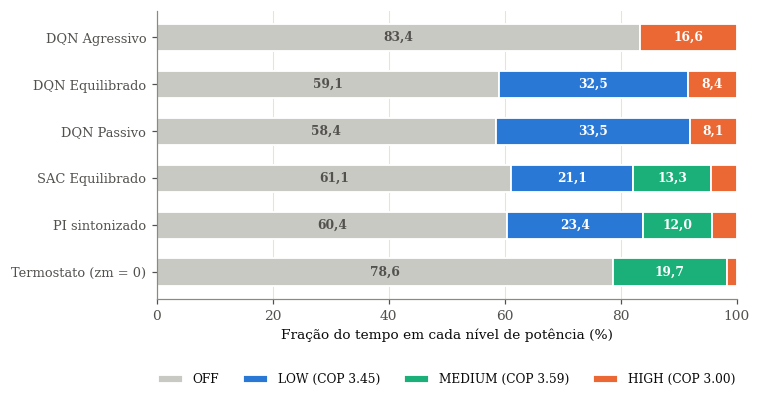

In [3]:
fig = F.fig_uso_dos_niveis(niveis, cop=cop)
plt.close(fig)
fig

### Leitura

**Os três perfis usam MEDIUM 0,0 % do tempo**, apesar de pesos que variam por
fatores de 3× a 4×. O Agressivo é ainda mais extremo: descarta LOW **e** MEDIUM,
operando só em OFF (83,4 %) e HIGH (16,6 %) — política puramente liga-desliga.

Já o **SAC**, treinado com a **mesma** função de recompensa do DQN Equilibrado,
usa MEDIUM 13,3 % do tempo — praticamente igual ao PI (12,0 %).

Isso é um controle experimental limpo: mesma recompensa, comportamentos opostos.
A causa **não é a recompensa**; é a política discreta de argmax.

## 5.2 É um problema de custo-benefício? Sim.

MEDIUM é o nível de **melhor COP** do equipamento (3,59, contra 3,45 do LOW e
3,00 do HIGH) — o modelo físico reproduz o pico de eficiência em carga parcial,
comportamento de equipamento *inverter*. Descartá-lo significa operar nos níveis
menos eficientes.

In [4]:
dec = R.consumo_decomposto()
dec["por_nivel"].pivot(index="controlador", columns="nivel",
                       values="kwh_dia").round(2)

nivel,HIGH,LOW,MEDIUM,OFF
controlador,,,,
DQN Equilibrado,5.93,4.97,0.00,0.00
PI sintonizado,2.93,3.58,3.89,0.00
SAC Equilibrado,2.54,3.01,4.46,1.34
Termostato (zm = 0),1.17,0.00,6.38,0.00


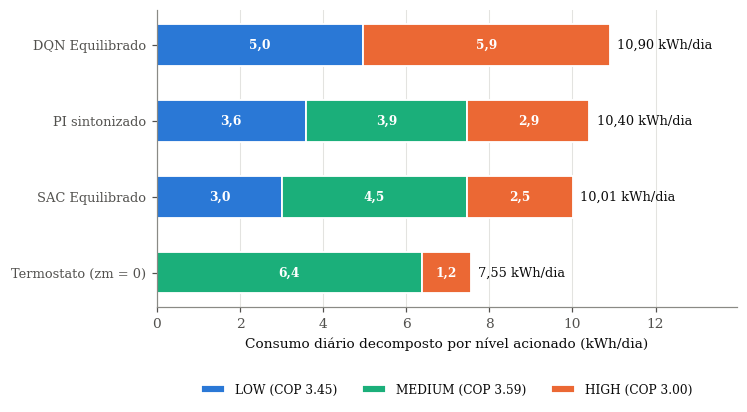

In [5]:
fig = F.fig_consumo_decomposto(dec, cop=cop)
plt.close(fig)
fig

### Leitura

O DQN Equilibrado gasta 10,90 kWh/dia contra 10,40 do PI — **4,7 % a mais** para
entregar o mesmo conforto. E a energia extra não vem de operar mais tempo (ambos
ficam ~55 % em OFF): vem de **operar nos níveis errados**, com o dobro de HIGH.

Portanto sim, é um problema de custo-benefício — e é o único mecanismo
identificado que explica quantitativamente a diferença de energia entre os dois.

## 5.3 Vale ajustar a recompensa? O que os Q-values dizem

Se MEDIUM fosse fortemente dominado, ajustar pesos não adiantaria. Se estivesse
em segundo lugar por pouco, um ajuste pequeno o traria de volta. A resposta exige
olhar a **escala** dos Q-values, e não só o ranking.

In [6]:
R.analise_q_values().round(2)

,controlador,posicao_medium,deficit_medium,faixa_entre_acoes,q_absoluto,faixa_pct_do_valor,deficit_pct_do_valor,argmax_medium_pct
0,DQN Agressivo,3.21,9.90,15.73,1133.03,1.39,0.87,0.0
1,DQN Equilibrado,3.27,11.70,18.44,983.20,1.88,1.19,0.0
2,DQN Passivo,3.21,9.71,15.43,934.36,1.65,1.04,0.0


### Leitura — cuidado com a escala

MEDIUM fica em **terceiro lugar** no ranking (posição média 3,2 de 4) nos três
perfis, e nunca é o argmax.

Mas o déficit precisa ser lido na escala certa. O Q-value absoluto é da ordem de
**980**; a faixa inteira entre as quatro ações vale **~1,9 %** desse valor, e o
déficit de MEDIUM para o topo é de **~1,2 %**.

> Dizer que "MEDIUM perde 63 % da faixa de Q" seria tecnicamente verdadeiro e
> substantivamente enganoso — sugeriria uma ação ruim, quando as quatro são
> **quase equivalentes em valor**.

O mecanismo real é *winner-take-all*: **uma política greedy determinística
converte uma margem de ~1 % em uso de 0 %.** Não existe "usar MEDIUM às vezes"
sob argmax — ou a ação é a melhor num estado, ou não aparece nunca.

**Consequência prática:** mexer nos pesos da recompensa é o caminho errado. Os
três perfis já cobrem uma variação de 3–4× e todos colapsam igual. O que restaura
o uso dos níveis intermediários é mudar a **classe de política** — estocástica ou
contínua, como o SAC demonstra —, não reponderar termos.

## 5.4 Quem mantém melhor a faixa? Conjunto amplo e independente

A matriz 3×3 tem nove pontos e foi usada para sintonizar o PI. Empregam-se
aqui **150 cenários aleatórios** sobre o espaço contínuo (temperatura inicial 16–33 °C,
ocupação 0–45, hora 0–23), com semente fixa distinta das de treino. Todos os
controladores veem **exatamente os mesmos** cenários — comparação emparelhada.

Para o PI este é um teste **fora da amostra**: ele foi sintonizado noutro
conjunto.

In [7]:
al = R.cenarios_aleatorios_cache()
al.groupby("controlador").agg(
    conf_larga=("conf_larga_pct", "mean"),
    conf_estreita=("conf_estreita_pct", "mean"),
    na_tolerancia=("na_tolerancia_pct", "mean"),
    desvio=("desvio_ideal", "mean"),
    kwh_dia=("energia_kwh", "mean"),
).sort_values("na_tolerancia", ascending=False).round(2)

,conf_larga,conf_estreita,na_tolerancia,desvio,kwh_dia
controlador,,,,,
DQN Agressivo,87.88,83.28,79.62,0.69,12.16
PI sintonizado,87.88,83.28,79.18,0.62,10.77
DQN Equilibrado,87.88,83.24,72.85,0.76,11.06
DQN Passivo,87.88,83.03,71.68,0.77,10.85
SAC Equilibrado,77.89,61.77,35.59,1.29,11.90
Termostato (zm = 1 °C),82.02,19.32,6.91,1.66,8.44
Termostato (zm = 0),56.28,12.03,5.00,1.99,7.74


### Leitura — a resposta depende de qual faixa se pergunta

| Critério | Melhor | Valor |
|---|---|---|
| Faixa larga [22, 26] °C | **empate** entre PI e os 3 DQN | 87,88 % |
| Faixa estreita [23, 25] °C | empate PI / DQN Agressivo | 83,28 % |
| Tolerância ±0,5 °C | DQN Agressivo, por 0,44 pp | 79,62 % vs 79,18 % |
| Desvio médio \|T−24\| | **PI** | 0,62 °C |
| Energia | **PI** (entre os que controlam) | 10,77 kWh/dia |

Na faixa larga os quatro dão **exatamente 87,88 %** — a métrica está saturada, e
o valor é determinado pelo transitório de *pulldown*, que é limitado pela física
e não pelo controlador. Ela não discrimina nada.

Na tolerância de ±0,5 °C aparece separação real, e ali o **DQN Agressivo alcança
o PI** (79,62 % contra 79,18 %). Este é um resultado favorável ao RL, e mais
honesto do que a matriz 3×3 sugeria — mas veja o custo na Seção 5.6.

O PI **se sustenta fora da amostra**, o que atenua (sem eliminar) a ressalva de
que ele havia sido sintonizado no mesmo conjunto de avaliação.

## 5.5 Onde os modelos divergem

A média esconde a distribuição. Agrupando por condição do cenário:

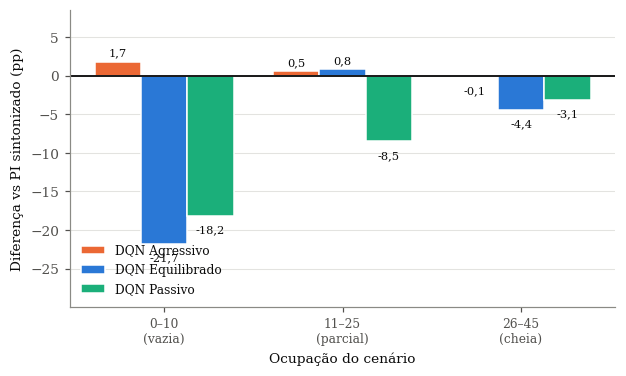

In [8]:
fig = F.fig_divergencia_por_condicao(al)
plt.close(fig)
fig

In [9]:
cond = al.drop_duplicates("cenario").set_index("cenario")[["start_temp","occupancy","hour"]]
piv = al.pivot(index="cenario", columns="controlador",
               values="na_tolerancia_pct").join(cond)
piv["dif"] = piv["DQN Equilibrado"] - piv["PI sintonizado"]
piv.nsmallest(6, "dif")[["start_temp", "occupancy", "hour",
                         "PI sintonizado", "DQN Equilibrado", "dif"]].round(1)

,start_temp,occupancy,hour,PI sintonizado,DQN Equilibrado,dif
cenario,,,,,,
R064,30.9,0,2,100.0,37.3,-62.7
R027,26.5,1,4,100.0,40.0,-60.0
R067,28.0,2,6,97.3,45.3,-52.0
R041,26.8,4,4,100.0,58.7,-41.3
R117,29.9,4,3,100.0,58.7,-41.3
R068,27.4,1,8,85.3,46.7,-38.7


### Leitura — a falha é concentrada, não difusa

O déficit dos perfis Equilibrado e Passivo vive quase todo em **salas vazias**:
−21,7 pp e −18,2 pp com 0–10 ocupantes, contra −4,4 pp e −3,1 pp com a sala
cheia.

Os piores cenários têm assinatura comum: **ocupação 0–4 pessoas, madrugada
(2h–6h)**. Ali o PI atinge 100 % dentro da tolerância e o DQN cai para 37–58 %.

**Mecanismo:** com a sala vazia de madrugada, a carga térmica é mínima, e manter
±0,5 °C exige potência muito baixa e finamente dosada. O menor nível não-nulo
disponível (LOW, 25 % da capacidade) já é excessivo — então o agente oscila entre
resfriar demais e deixar subir. O PI resolve alternando com o ciclo certo, obtendo
uma média efetiva menor que qualquer nível isolado.

O DQN Agressivo **não** sofre disso (+1,7 pp em sala vazia), porque opera em
liga-desliga puro e, sem penalidade de energia relevante, aciona HIGH sem
hesitação — mas paga na conta de luz.

## 5.6 A fronteira de Pareto: cada perfil falha de um jeito

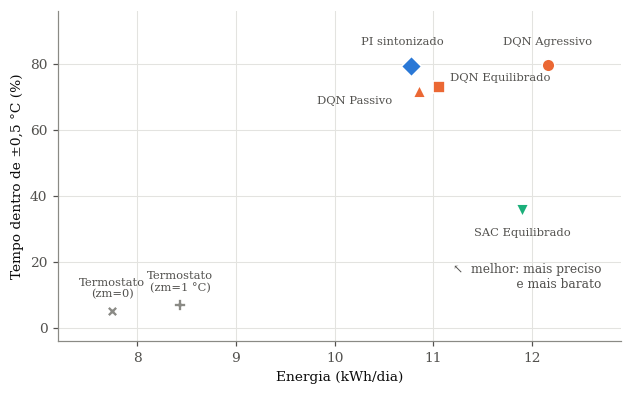

In [10]:
fig = F.fig_pareto_aleatorios(al)
plt.close(fig)
fig

In [11]:
g = al.groupby("controlador").agg(tol=("na_tolerancia_pct","mean"),
                                  kwh=("energia_kwh","mean"))
pi = g.loc["PI sintonizado"]
comp = g.loc[["DQN Agressivo","DQN Equilibrado","DQN Passivo","SAC Equilibrado"]].copy()
comp["dif_tolerancia_pp"] = comp["tol"] - pi["tol"]
comp["dif_energia_pct"] = (comp["kwh"] / pi["kwh"] - 1) * 100
comp.round(2)

,tol,kwh,dif_tolerancia_pp,dif_energia_pct
controlador,,,,
DQN Agressivo,79.62,12.16,0.44,12.86
DQN Equilibrado,72.85,11.06,-6.33,2.61
DQN Passivo,71.68,10.85,-7.50,0.72
SAC Equilibrado,35.59,11.90,-43.59,10.45


### Leitura — nenhum perfil domina o PI

| Perfil | Conforto vs PI | Energia vs PI | Diagnóstico |
|---|---|---|---|
| DQN Agressivo | **+0,4 pp** | **+12,9 %** | compra conforto com energia |
| DQN Equilibrado | −6,3 pp | +2,7 % | perde conforto sem economizar |
| DQN Passivo | −7,5 pp | +0,7 % | perde conforto sem economizar |
| SAC Equilibrado | −43,6 pp | +10,5 % | pior nos dois eixos |

Esta é a assinatura de estar **abaixo da fronteira de Pareto**: para igualar o PI
em conforto é preciso gastar 12,9 % mais energia; para igualar em energia é
preciso perder 6–7 pontos de conforto. O PI ocupa sozinho o canto ótimo.

E note que os três perfis foram obtidos **variando apenas pesos da recompensa** —
que era a tese central do manuscrito. A variação move o agente ao longo de uma
curva que passa **inteiramente por dentro** da fronteira, sem tocá-la.

## 5.8 Velocidade de resposta: quanto tempo até a sala ficar utilizável

Todas as métricas até aqui medem **qualidade em regime** — fração do tempo dentro
da faixa, desvio, energia. Nenhuma media **velocidade**, que é requisito
operacional real: uma sala que leva quatro horas para ficar utilizável é um
problema mesmo que depois se mantenha perfeita.

Esta seção também testa uma afirmação feita anteriormente **sem medição**: a de
que o conforto idêntico entre controladores (Seção 5.4) decorre de um transitório
limitado pela física. Se os tempos diferirem, aquela explicação está errada.

Reportamos três grandezas distintas — entrar na faixa, parar de sair dela, e
quanto se passou do outro lado — sobre os cenários que **começam fora** da faixa.

In [12]:
tr = R.resposta_transitoria()
tr.groupby("controlador").agg(
    entrada_h=("entrada_h", "mean"), desvio=("entrada_h", "std"),
    acomodacao_h=("acomodacao_h", "mean"), taxa_c_h=("taxa_c_por_h", "mean"),
    saturacao_pct=("saturacao_pct", "mean"),
    kwh_transitorio=("energia_transitorio_kwh", "mean"),
).sort_values("entrada_h").round(2)

,entrada_h,desvio,acomodacao_h,taxa_c_h,saturacao_pct,kwh_transitorio
controlador,,,,,,
DQN Agressivo,1.27,0.89,1.27,2.47,100.00,3.79
DQN Equilibrado,1.27,0.89,1.27,2.47,100.00,3.79
DQN Passivo,1.27,0.89,1.27,2.47,100.00,3.79
PI sintonizado,1.27,0.89,1.27,2.47,100.00,3.79
Termostato (zm = 0),1.99,1.33,21.33,1.56,28.45,3.85
Termostato (zm = 1 °C),1.99,1.33,19.45,1.56,28.45,3.85
SAC Equilibrado,3.91,2.59,4.73,0.96,30.50,3.32


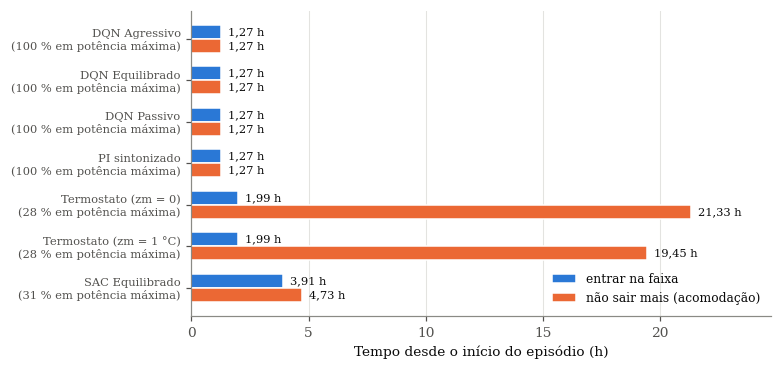

In [13]:
fig = F.fig_transitorio(tr)
plt.close(fig)
fig

### Leitura — a explicação anterior se confirma

| Controlador | Entrar | Acomodar | Potência máxima |
|---|---|---|---|
| PI e os três DQN | **1,27 h** | **1,27 h** | **100 %** |
| Termostato (ambos) | 1,99 h | 19–21 h | 28 % |
| SAC Equilibrado | 3,91 h | 4,73 h | 31 % |

**PI e os três perfis DQN têm tempo idêntico — divergem em 0 de 48 cenários.** O
motivo aparece na última coluna: todos saturam o atuador, operando em potência
máxima durante 100 % do transitório. No *pulldown* não existe decisão a tomar; a
única ação sensata é potência total, e a velocidade fica limitada pela física do
equipamento. Isso confirma a explicação dada na Seção 5.4 para o conforto
idêntico, que até aqui era inferência.

O **termostato** revela seu defeito na distância entre as duas barras: entra na
faixa em 1,99 h, mas leva cerca de **20 horas** para parar de sair dela. Ele
estaciona no teto e oscila em torno de 26 °C — entra e sai repetidamente. A
métrica de primeira entrada o favoreceria indevidamente; a de acomodação expõe o
comportamento.

O **SAC** é **3,1× mais lento** que o PI, e a causa é a mesma coluna: satura o
atuador em apenas 31 % do transitório. Ele hesita onde não há razão para hesitar.

### Uma observação sobre o conjunto de métricas

Esta é a **terceira métrica saturada** encontrada: conforto na faixa larga,
conforto na faixa estreita sobre cenários aleatórios, e agora velocidade de
resposta. Em todas, PI e DQN produzem valores indistinguíveis.

Isso não é coincidência estatística — é a assinatura de um problema com pouco
espaço para diferenciação. Fora do regime permanente, a política ótima é trivial
(potência máxima) e qualquer controlador competente a encontra. A diferenciação
existe apenas no regime permanente, e ali quem decide é a resolução da atuação —
onde o agente discreto perde, pelas razões da Seção 5.3.

## 5.9 Síntese

1. **O descarte de MEDIUM é real e custa dinheiro.** Os três perfis o descartam
   completamente; o nível tem o melhor COP; a energia extra do DQN vem daí.
2. **Não adianta ajustar a recompensa.** Os perfis já variam os pesos por 3–4× e
   colapsam igual. As quatro ações têm Q-values dentro de ~2 %, e o argmax
   converte ~1 % de margem em 0 % de uso.
3. **O que restaura os níveis intermediários é a classe de política.** O SAC, com
   a mesma recompensa, usa MEDIUM como o PI. Política contínua ou estocástica —
   não reponderação.
4. **Na faixa larga ninguém se distingue** (87,88 % para todos): a métrica é
   limitada pela física do *pulldown*. Só a tolerância estreita discrimina.
5. **A falha é concentrada em salas vazias de madrugada**, onde o menor nível
   disponível já é potência demais.
6. **Nenhum perfil domina o PI** — cada um erra por um eixo diferente.
7. **Velocidade de resposta não discrimina**: PI e DQN entram na faixa em tempo
   idêntico, porque ambos saturam o atuador. O termostato entra rápido mas leva
   ~20 h para parar de sair; o SAC é 3,1× mais lento por hesitar.

**Recomendação prática:** se o objetivo for aplicar RL neste equipamento, o ganho
mais direto não está na recompensa, e sim em dar ao agente **autoridade de
atuação mais fina** — ação contínua, ou modulação por ciclo de trabalho entre
níveis. Sem isso, a política aprendida fica presa aos extremos e paga a diferença
em energia.